Merge Complete: 2177 rows created from two sources.


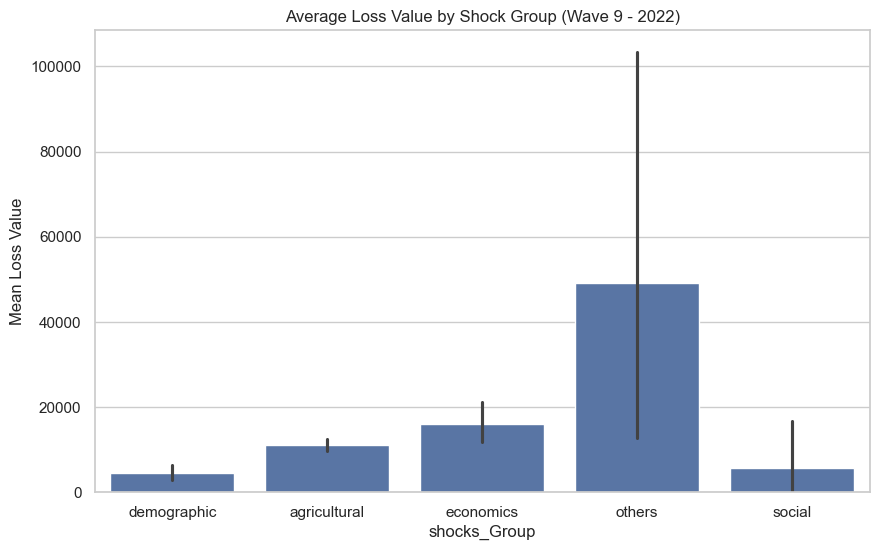

✅ Wave 9 Complete! Master File: shocks_2022_final_harmonized.csv


In [1]:
# ==============================================================================
# STEP 1: SETUP & LIBRARIES
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ==============================================================================
# STEP 2: DATA LOADING & MERGING (Crucial for Wave 9)
# ==============================================================================
# Why: ปี 2022 ข้อมูลแยกเป็น 2 ตาราง เราต้องรวมกันเพื่อให้ได้ทั้ง "ประเภท" และ "มูลค่าความเสียหาย"
df_shocks = pd.read_stata('wave-9-shocks.dta', convert_categoricals=False)
df_detail = pd.read_stata('wave-9-shocks_detail.dta', convert_categoricals=False)

# รวมข้อมูลด้วย interview__key และ shocks__id
df_22 = pd.merge(df_shocks, df_detail, on=['interview__key', 'shocks__id'], how='inner')

print(f"Merge Complete: {len(df_22)} rows created from two sources.")

# ==============================================================================
# STEP 3: ADVANCED DATA CLEANING
# ==============================================================================
def clean_wave9_improved(df):
    # 1. จัดการค่าว่างมาตรฐาน Stata
    df = df.replace([-9, -99, -9.0, -99.0], np.nan)
    
    # 2. จัดการคำว่า 'none' ในคอลัมน์เงิน และ 'not yet recovered' ในคอลัมน์ระยะเวลา
    numeric_cols = ['v31105a', 'shockmoneyloss', 'v31112a']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace('none', '0', case=False)
            df[col] = df[col].str.replace('not yet recovered', '999', case=False) # รหัสสมมติสำหรับเซนเซอร์ข้อมูล
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
            
    return df

df_22 = clean_wave9_improved(df_22)

# ==============================================================================
# STEP 4: COPING HARMONIZATION (Rename for Consistency)
# ==============================================================================
# Why: เปลี่ยนชื่อเพื่อให้เวลา Concat กับปีเก่าๆ คอลัมน์จะเรียงต่อกันอัตโนมัติ
coping_rename = {
    'v31108a__1': 'coping_used_savings',
    'v31108a__2': 'coping_used_insurance',
    'v31108a__3': 'coping_borrowed_informal',
    'v31108a__4': 'coping_borrowed_formal',
    'v31108a__5': 'coping_sold_assets',
    'v31108a__7': 'coping_gov_help'
}
df_22 = df_22.rename(columns=coping_rename)

# ==============================================================================
# STEP 5: SHOCK CATEGORIZATION
# ==============================================================================
# หมายเหตุ: ปี 2022 ใน shocks.dta มักจะมี typeshock เป็นตัวอักษรมาให้แล้ว 
# แต่เราจะรัน Logic เพื่อ Re-check ความถูกต้องอีกครั้ง
shock_group_logic = {
    10: 'agricultural', 11: 'agricultural', 63: 'agricultural', 55: 'agricultural',
    1: 'demographic', 2: 'demographic', 3: 'demographic', 24: 'demographic',
    5: 'economics', 6: 'economics', 18: 'economics', 21: 'economics', 22: 'economics', 62: 'economics',
    8: 'social', 70: 'social', 77: 'economics'
}

df_22['shocks_Group'] = df_22['shocks__id'].map(shock_group_logic).fillna('others')
df_22['survey_year'] = 2022

# ==============================================================================
# STEP 6: EXPORT
# ==============================================================================
output_file = 'shocks_2022_final_harmonized.csv'
df_22.to_csv(output_file, index=False)

# Visualization: เปรียบเทียบความเสียหายเฉลี่ยรายกลุ่ม
plt.figure(figsize=(10, 6))
sns.barplot(data=df_22, x='shocks_Group', y='v31105a', estimator=np.mean)
plt.title('Average Loss Value by Shock Group (Wave 9 - 2022)')
plt.ylabel('Mean Loss Value')
plt.show()

print(f"✅ Wave 9 Complete! Master File: {output_file}")